# Noise Robustness of Torus Recovery via Delay Embedding

**Reviewer question:** *What is the minimum SNR or spectral prominence required for correct torus recovery?*

**Setup:** We generate a fixed AR(3) process with known pole structure (same as Figure 3),
inject additive white Gaussian noise at controlled SNR levels, and measure how the
delay-embedded manifold degrades. We report:

1. **Visual** degradation of the 3D delay embedding across SNR levels
2. **Quantitative metrics** — reconstruction correlation, PSD divergence, and torus score (TBD)
3. **Critical SNR threshold** where torus topology is lost

In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy import signal as sig
from scipy import optimize
from joblib import Parallel, delayed
from NeuralFieldManifold.embedders import embed
from NeuralFieldManifold.fits import two_torus_fit, one_torus_fit, plot_one_torus_fit, plot_two_torus_fit

# ============== GLOBAL PLOT STYLE (matches PINN notebook) ==============
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "lines.linewidth": 1.8,
    "lines.markersize": 5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
})

color_main = "black"
color_alt = "black"

def prettify(ax, title=None, xlabel=None, ylabel=None, add_legend=False):
    """Unified styling for axes."""
    if title: ax.set_title(title, pad=10)
    if xlabel: ax.set_xlabel(xlabel, labelpad=5)
    if ylabel: ax.set_ylabel(ylabel, labelpad=5)
    ax.grid(alpha=0.0, linestyle="--", linewidth=0.7)
    if add_legend:
        ax.legend(frameon=False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(1.0)

print("Plot style configured.")

Plot style configured.


## 1. Signal Generation & Noise Injection

In [2]:
def generate_oscillatory_ar(n_samples=5000, ar_order=2, noise_level=0.03, seed=None,
                            burnin=50000):
    """AR process with oscillatory (complex conjugate) poles driven by white noise.
    Poles are tight to the unit circle so the clean signal forms a clear torus."""
    rng = np.random.default_rng(seed)
    n_total = n_samples + burnin

    if ar_order == 2:
        rho = 0.997
        theta = 2 * np.pi * 0.015
        a1 = 2 * rho * np.cos(theta)
        a2 = -(rho ** 2)
        coeffs = [a1, a2]

    elif ar_order == 4:
        rho1, theta1 = 0.999, 2 * np.pi * 0.025
        rho2, theta2 = 0.993, 2 * np.pi * 0.25
        b1, c1 = 2 * rho1 * np.cos(theta1), rho1 ** 2
        b2, c2 = 2 * rho2 * np.cos(theta2), rho2 ** 2
        coeffs = [
            b1 + b2,
            -(c1 + c2 + b1 * b2),
            b1 * c2 + b2 * c1,
            -(c1 * c2),
        ]
    else:
        raise ValueError("ar_order must be 2 or 4")

    x = np.zeros(n_total, dtype=np.float64)
    x[:ar_order] = rng.standard_normal(ar_order)
    for i in range(ar_order, n_total):
        x[i] = sum(coeffs[j] * x[i - j - 1] for j in range(ar_order)) \
               + noise_level * rng.standard_normal()
    return x[burnin:]


def envelope_normalize(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x)) * 2 - 1


def add_noise_at_snr(x_clean, snr_db, rng=None):
    """Add white Gaussian noise at a specified SNR (dB)."""
    if rng is None:
        rng = np.random.default_rng()
    p_signal = np.mean(x_clean ** 2)
    p_noise = p_signal / (10 ** (snr_db / 10))
    noise = rng.standard_normal(len(x_clean)) * np.sqrt(p_noise)
    return x_clean + noise


def make_windows(xs, Fs, embedding_dim, tau, starts_sec, window_sec=2):
    window_samples = int(window_sec * Fs)
    windows = []
    for t in starts_sec:
        start = int(t * Fs)
        segment = xs[start:start + window_samples]
        pts = np.asarray(embed(segment, embedding_dim, tau))
        windows.append({
            'points': pts,
            'start_sec': t,
            'end_sec': t + window_sec,
        })
    return windows


def sweep_fits(windows, fit_fn, lam=1.0, n_jobs=-1, **kwargs):
    fits = Parallel(n_jobs=n_jobs)(
        delayed(fit_fn)(w['points'], lam=lam, **kwargs)
        for w in windows
    )
    return [{**w, **f} for w, f in zip(windows, fits)]

In [3]:
# --- Parameters ---
AR_ORDERS = [2, 4]
N_SAMPLES = 5000
FS = 100
M = 3                 # embedding dimension
TAUS = {2: 13, 4: 10} # per-order lag (matches donut notebook)
NOISE_LEVELS = {2: 0.02*100, 4: 0.05*100}
LAMS = {2: 1, 4: 1}
HOLE_RATIOS = {2: 0.7, 4: 0.5}
FIT_FNS = {2: one_torus_fit, 4: two_torus_fit}

SNR_LEVELS_DB = [0, 5, 10, 15, 20, 25, 30]
SNR_VIZ = [30, 20, 10, 5]
N_TRIALS = 10          # random noise seeds per SNR
WINDOW_SEC = 4
N_WINDOWS = 5          # random window starts per trial

# Generate clean signals
clean_signals = {}
for p in AR_ORDERS:
    x = envelope_normalize(
        generate_oscillatory_ar(N_SAMPLES, ar_order=p,
                                noise_level=NOISE_LEVELS[p], seed=42)
    )
    clean_signals[p] = x
    print(f"AR({p}): {len(x)} samples, tau={TAUS[p]}, lam={LAMS[p]}")

t = np.arange(N_SAMPLES) / FS
print(f"\nSNR grid: {SNR_LEVELS_DB} dB")
print(f"Trials per SNR: {N_TRIALS}, windows per trial: {N_WINDOWS}")

AR(2): 5000 samples, tau=13, lam=1
AR(4): 5000 samples, tau=10, lam=1

SNR grid: [0, 5, 10, 15, 20, 25, 30] dB
Trials per SNR: 10, windows per trial: 5


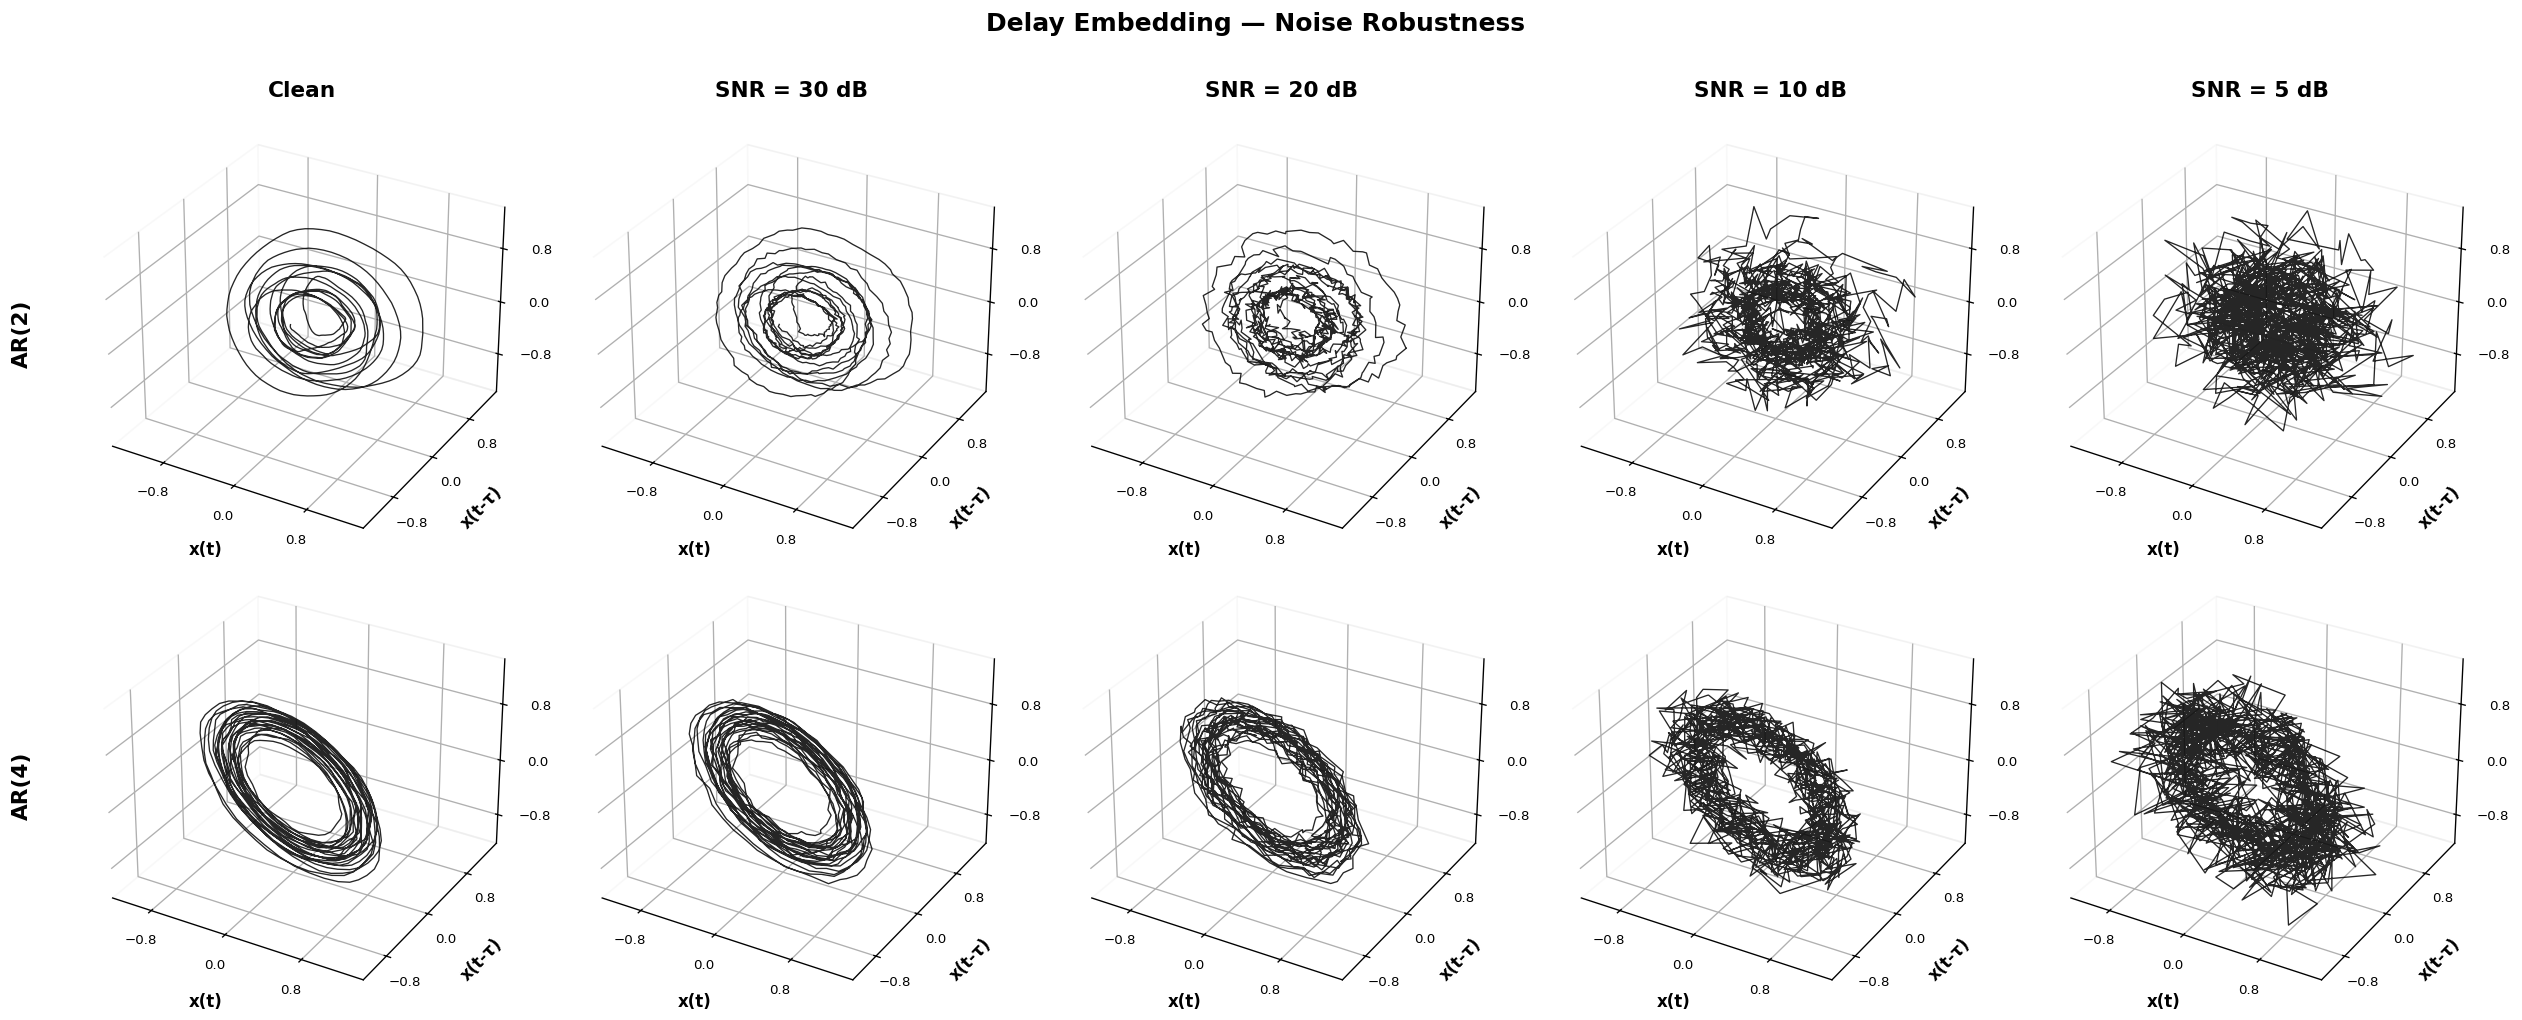

In [4]:
from matplotlib.ticker import MaxNLocator

all_snrs_viz = ["Clean"] + SNR_VIZ
ncols = len(all_snrs_viz)
nrows = len(AR_ORDERS)

fig = plt.figure(figsize=(4.2 * ncols, 4.2 * nrows))

for row, p in enumerate(AR_ORDERS):
    x_clean_p = clean_signals[p]
    tau = TAUS[p]
    X_clean_p = np.asarray(embed(x_clean_p[:1000], m=M, tau=tau))

    # Pre-compute embeddings for consistent axis limits
    rng = np.random.default_rng(0)
    embs = [X_clean_p]
    for snr_db in SNR_VIZ:
        x_noisy = add_noise_at_snr(x_clean_p, snr_db, rng=rng)
        embs.append(np.asarray(embed(x_noisy[:1000], m=M, tau=tau)))
    all_pts = np.concatenate(embs, axis=0)
    pad = 0.05 * (all_pts.max() - all_pts.min())
    ax_min, ax_max = all_pts.min() - pad, all_pts.max() + pad

    rng = np.random.default_rng(0)
    for col, snr_db in enumerate(all_snrs_viz):
        idx = row * ncols + col + 1
        if snr_db == "Clean":
            X_emb = X_clean_p
            label = "Clean"
        else:
            x_noisy = add_noise_at_snr(x_clean_p, snr_db, rng=rng)
            X_emb = np.asarray(embed(x_noisy[:1000], m=M, tau=tau))
            label = f"SNR = {snr_db} dB"

        ax = fig.add_subplot(nrows, ncols, idx, projection="3d")
        ax.plot(X_emb[:, 0], X_emb[:, 1], X_emb[:, 2], lw=0.8, alpha=0.85, color=color_alt)

        if row == 0:
            ax.set_title(label, fontsize=13, pad=8, fontweight="bold")
        if col == 0:
            ax.text2D(-0.15, 0.5, f"AR({p})", transform=ax.transAxes,
                       fontsize=13, fontweight="bold", va="center", rotation=90)

        ax.set_xlim(ax_min, ax_max)
        ax.set_ylim(ax_min, ax_max)
        ax.set_zlim(ax_min, ax_max)

        ax.set_xlabel("x(t)", labelpad=6, fontsize=10, fontweight="bold")
        ax.set_ylabel("x(t-τ)", labelpad=6, fontsize=10, fontweight="bold")
        ax.zaxis.set_rotate_label(False)
        ax.set_zlabel("x(t-2τ)", labelpad=10, fontsize=10, fontweight="bold", rotation=90)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.zaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.tick_params(axis='both', pad=2, labelsize=8)
        ax.tick_params(axis='z', pad=6)
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False

plt.suptitle("Delay Embedding — Noise Robustness",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [5]:
# --- Compute torus metrics: one big sweep_fits call per AR order ---

max_start = (N_SAMPLES / FS) - WINDOW_SEC - 1

# fitted_results[p] = list of dicts (one per window), each with full fit output + 'snr_db'
# summary[p] = aggregated mean/std per SNR level for plotting
fitted_results = {}
summary = {}

for p in AR_ORDERS:
    x_clean_p = clean_signals[p]
    tau = TAUS[p]
    lam = LAMS[p]
    hr = HOLE_RATIOS[p]
    fit_fn = FIT_FNS[p]

    # Collect ALL windows across ALL SNR levels and trials
    all_windows = []
    window_snr = []

    for snr_db in SNR_LEVELS_DB:
        for trial in range(N_TRIALS):
            rng_trial = np.random.default_rng(trial)
            x_noisy = add_noise_at_snr(x_clean_p, snr_db, rng=rng_trial)

            rng_wins = np.random.default_rng(trial + 1000)
            starts = sorted(rng_wins.uniform(0, max_start, size=N_WINDOWS))

            windows = make_windows(x_noisy, FS, M, tau, starts, window_sec=WINDOW_SEC)
            all_windows.extend(windows)
            window_snr.extend([snr_db] * len(windows))

    # One single parallelized call — each entry keeps full fit dict + points
    fitted = sweep_fits(all_windows, fit_fn, lam=lam, n_jobs=-1, hole_ratio=hr)

    # Tag each result with its SNR
    for f, snr in zip(fitted, window_snr):
        f['snr_db'] = snr

    fitted_results[p] = fitted

    # Build summary for plotting
    snr_arr = np.array(window_snr)
    s = {}
    for snr_db in SNR_LEVELS_DB:
        mask = snr_arr == snr_db
        idxs = np.where(mask)[0]
        me = np.array([fitted[i]['mean_error'] for i in idxs])
        fr = np.array([fitted[i]['frac_inside'] for i in idxs])
        r2 = np.array([fitted[i]['r_squared'] for i in idxs])
        s[snr_db] = {'mean_error': me, 'frac_inside': fr, 'r_squared': r2}

    summary[p] = s
    print(f"AR({p}) done — {len(fitted)} total fits.")

print("All orders computed.")
print(f"\n# Inspect individual fits:")
print(f"#   fitted_results[2][0]  — first AR(2) window (has 'points', all fit keys)")
print(f"#   fitted_results[4][0]  — first AR(4) window")
print(f"#   summary[2][30]        — AR(2) at SNR=30 dB, arrays of per-window metrics")

AR(2) done — 350 total fits.
AR(4) done — 350 total fits.
All orders computed.

# Inspect individual fits:
#   fitted_results[2][0]  — first AR(2) window (has 'points', all fit keys)
#   fitted_results[4][0]  — first AR(4) window
#   summary[2][30]        — AR(2) at SNR=30 dB, arrays of per-window metrics


/tmp/ipykernel_3478587/1963327008.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


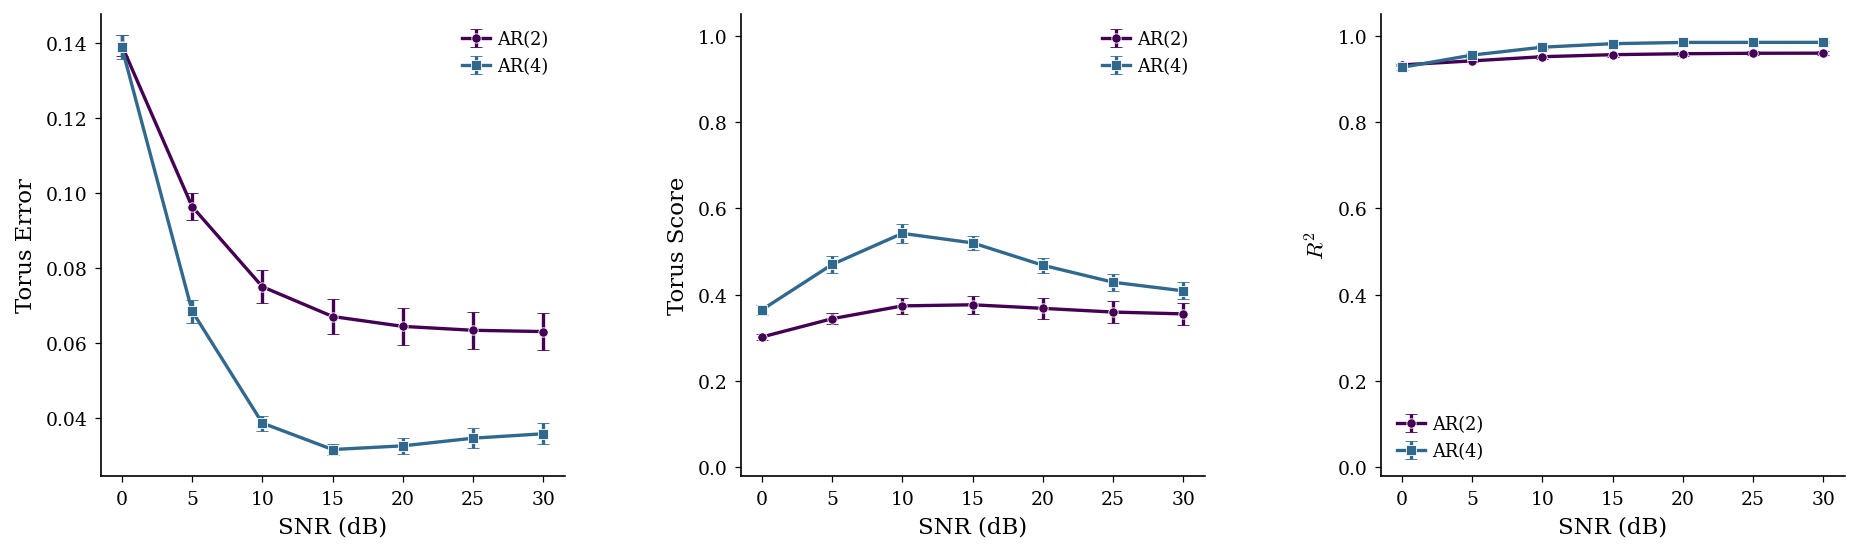

In [6]:
# --- Combined: Torus Error, Torus Score, R² vs. SNR (SEM error bars) ---
import matplotlib.colors as mcolors

_ICML_COLORS = ["#440154", "#31688e", "#35b779", "#fde725"]
_MARKERS     = ["o", "s", "D", "^"]

with plt.rc_context({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "lines.linewidth": 1.6,
    "lines.markersize": 4.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
}):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4), gridspec_kw={"wspace": 0.38})

    for i, p in enumerate(AR_ORDERS):
        s = summary[p]
        snr = np.array(SNR_LEVELS_DB)
        c  = _ICML_COLORS[i]
        mk = _MARKERS[i]

        me_mean = np.array([np.nanmean(s[db]['mean_error']) for db in SNR_LEVELS_DB])
        me_sem  = np.array([np.nanstd(s[db]['mean_error']) / np.sqrt(len(s[db]['mean_error'])) for db in SNR_LEVELS_DB])
        fr_mean = np.array([np.nanmean(s[db]['frac_inside']) for db in SNR_LEVELS_DB])
        fr_sem  = np.array([np.nanstd(s[db]['frac_inside']) / np.sqrt(len(s[db]['frac_inside'])) for db in SNR_LEVELS_DB])
        r2_mean = np.array([np.nanmean(s[db]['r_squared']) for db in SNR_LEVELS_DB])
        r2_sem  = np.array([np.nanstd(s[db]['r_squared']) / np.sqrt(len(s[db]['r_squared'])) for db in SNR_LEVELS_DB])

        ax1.errorbar(snr, me_mean, yerr=me_sem,
                     marker=mk, color=c, label=f"AR({p})",
                     markeredgecolor="white", markeredgewidth=0.4,
                     capsize=3, capthick=1.0, zorder=3)

        ax2.errorbar(snr, fr_mean, yerr=fr_sem,
                     marker=mk, color=c, label=f"AR({p})",
                     markeredgecolor="white", markeredgewidth=0.4,
                     capsize=3, capthick=1.0, zorder=3)

        ax3.errorbar(snr, r2_mean, yerr=r2_sem,
                     marker=mk, color=c, label=f"AR({p})",
                     markeredgecolor="white", markeredgewidth=0.4,
                     capsize=3, capthick=1.0, zorder=3)

    for ax in (ax1, ax2, ax3):
        ax.set_xlabel("SNR (dB)")
        ax.legend(frameon=False, ncol=1, loc="best", handlelength=1.6,
                  columnspacing=0.8, handletextpad=0.4)
        ax.grid(False)

    ax1.set_ylabel("Torus Error")
    ax2.set_ylabel("Torus Score")
    ax3.set_ylabel("$R^2$")

    ax2.set_ylim(bottom=-0.02, top=1.05)
    ax3.set_ylim(bottom=-0.02, top=1.05)

    plt.tight_layout()
    plt.show()

In [7]:
# --- Visual comparison: Clean vs Max Noise for AR(2) and AR(4) ---
# Fit clean signals (no added noise)
clean_fits = {}
for p in AR_ORDERS:
    tau = TAUS[p]
    lam = LAMS[p]
    hr = HOLE_RATIOS[p]
    fit_fn = FIT_FNS[p]
    x_clean_p = clean_signals[p]
    wins = make_windows(x_clean_p, FS, M, tau, [1.0], window_sec=WINDOW_SEC)
    fitted_clean = sweep_fits(wins, fit_fn, lam=lam, n_jobs=1, hole_ratio=hr)
    clean_fits[p] = fitted_clean[0]

# Fit max-noise signals (SNR = 0 dB)
max_noise_fits = {}
for p in AR_ORDERS:
    tau = TAUS[p]
    lam = LAMS[p]
    hr = HOLE_RATIOS[p]
    fit_fn = FIT_FNS[p]
    x_clean_p = clean_signals[p]
    rng = np.random.default_rng(0)
    x_noisy = add_noise_at_snr(x_clean_p, snr_db=0, rng=rng)
    wins = make_windows(x_noisy, FS, M, tau, [1.0], window_sec=WINDOW_SEC)
    fitted_noisy = sweep_fits(wins, fit_fn, lam=lam, n_jobs=1, hole_ratio=hr)
    max_noise_fits[p] = fitted_noisy[0]

print("Clean and max-noise fits computed.")

Clean and max-noise fits computed.


In [8]:
# --- AR(2): Clean (no noise) ---
print("AR(2) — Clean")
plot_one_torus_fit(clean_fits[2])
plt.show()

AR(2) — Clean


In [9]:
# --- AR(2): Max Noise (SNR = 0 dB) ---
print("AR(2) — SNR = 0 dB")
plot_one_torus_fit(max_noise_fits[2])
plt.show()

AR(2) — SNR = 0 dB


In [10]:
# --- AR(4): Clean (no noise) ---
print("AR(4) — Clean")
plot_two_torus_fit(clean_fits[4])
plt.show()

AR(4) — Clean


In [11]:
# --- AR(4): Max Noise (SNR = 0 dB) ---
print("AR(4) — SNR = 0 dB")
plot_two_torus_fit(max_noise_fits[4])
plt.show()

AR(4) — SNR = 0 dB
